In [28]:
import numpy as np
from scipy.signal import firwin

In [29]:
# bậc 2
def sdm_order2(x):
    x = np.asarray(x, dtype=float)

    N = len(x)
    y = np.zeros(N)

    v1 = 0.0
    v2 = 0.0
    y_prev = 0

    for n in range(N):

        v1 = v1 + x[n] - y_prev

        v2 = v2 + v1

        if v2 >= 0:
            y[n] = 1
        else:
            y[n] = -1

        y_prev = y[n]

    return y

In [30]:
# cic bâc 2
def cic_order2(x, R):

    x = np.asarray(x, dtype=float)

    int1 = np.zeros(len(x))
    acc1 = 0.0

    for n in range(len(x)):
        acc1 = acc1 + x[n]
        int1[n] = acc1

    int2 = np.zeros(len(x))
    acc2 = 0.0

    for n in range(len(x)):
        acc2 = acc2 + int1[n]
        int2[n] = acc2
  
    decimated = int2[R-1::R]

    comb1 = np.zeros(len(decimated))

    comb1[0] = decimated[0]

    for n in range(1, len(decimated)):
        comb1[n] = decimated[n] - decimated[n-1]

    y = np.zeros(len(comb1))

    y[0] = comb1[0]

    for n in range(1, len(comb1)):
        y[n] = comb1[n] - comb1[n-1]

    return y

In [31]:
def design_fir():
    # Tần số lấy mẫu
    Fs = 32000
    fs_in = 2 * Fs          # 64 kHz

    # Thông số FIR
    Fpass = 0.4 * Fs        # 12.8 kHz
    Fstop = 0.5 * Fs        # 16 kHz
    Ntaps = 31

    # Thiết kế FIR thông thấp
    h = firwin(
        Ntaps,
        cutoff=Fpass,
        fs=fs_in
    )

    return h

In [32]:
def polyphase_decimate2(x, h):

    E0 = h[0::2]      
    E1 = h[1::2]      
    x_even = x[0::2]  
    x_odd  = x[1::2]  

   
    y_even = np.convolve(x_even, E0, mode='same')
    y_odd  = np.convolve(x_odd, E1, mode='same')

    y = y_even + y_odd

    return y, E0, E1

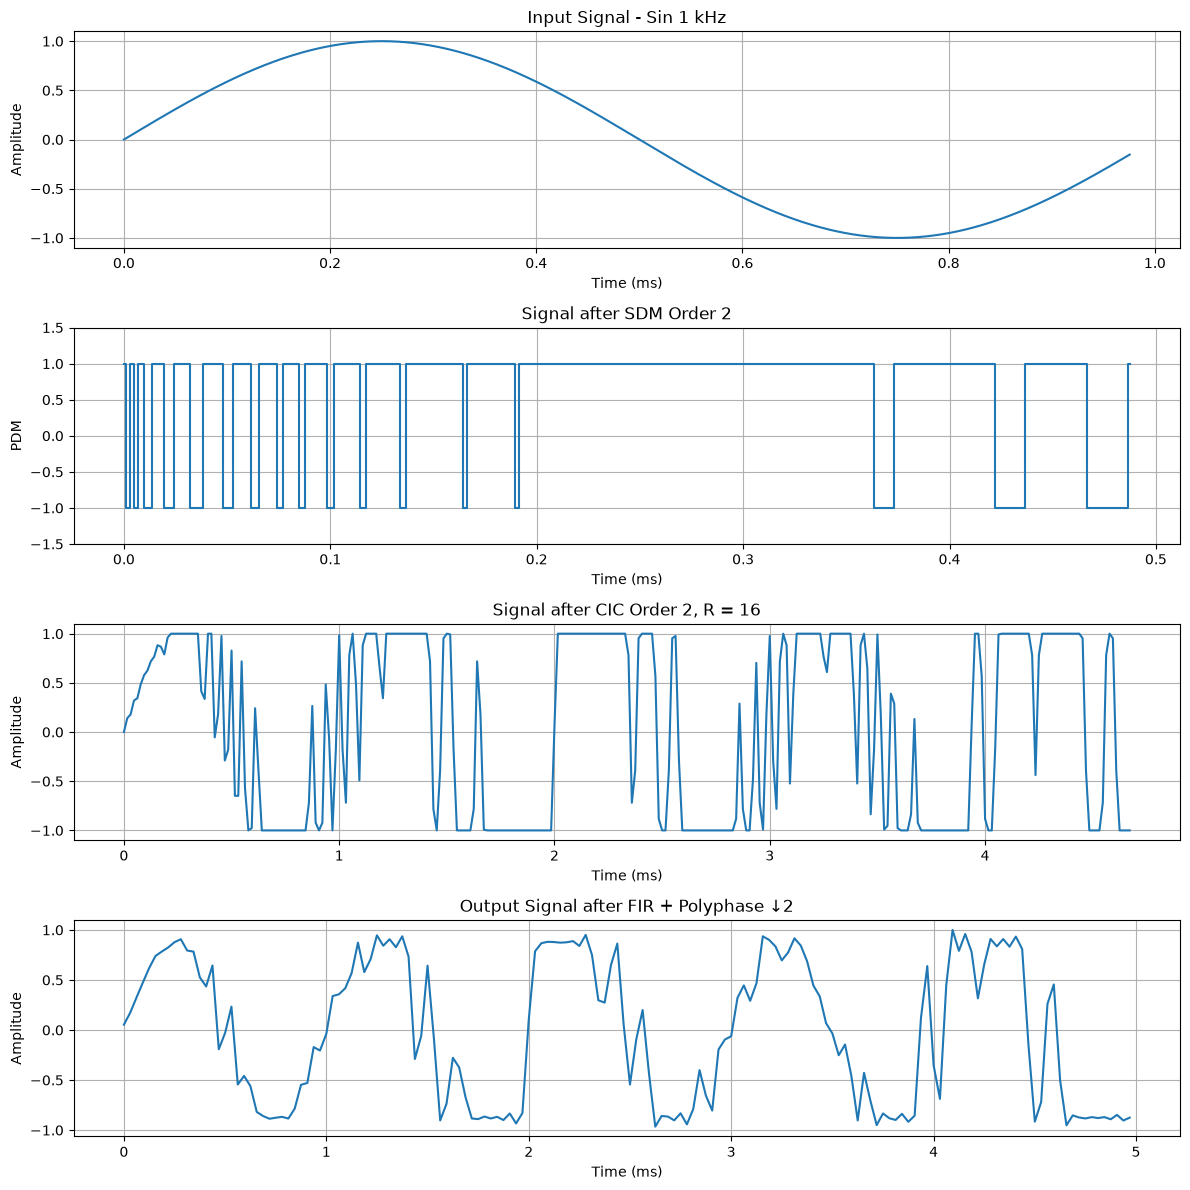

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Fs = 32000                 
K = 32
Fs_sdm = Fs * K            

R = K // 2                 
Fs_cic = Fs_sdm / R        
Fs_out = Fs_cic / 2        

f0 = 1000                  
duration = 0.005           



N = int(Fs_sdm * duration)

t_in = np.arange(N) / Fs_sdm

x = np.sin(2 * np.pi * f0 * t_in)



y_sdm = sdm_order2(x)



y_cic = cic_order2(y_sdm, R)



h = design_fir()


y_out, E0, E1 = polyphase_decimate2(y_cic, h)



t_sdm = np.arange(len(y_sdm)) / Fs_sdm

t_cic = np.arange(len(y_cic)) / Fs_cic

t_out = np.arange(len(y_out)) / Fs_out


y_cic_plot = y_cic / R**2


y_out_plot = y_out / np.max(np.abs(y_out))



plt.figure(figsize=(12, 12))


plt.subplot(4, 1, 1)

n = min(1000, len(x))

plt.plot(
    t_in[:n] * 1000,
    x[:n]
)

plt.title("Input Signal - Sin 1 kHz")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)



plt.subplot(4, 1, 2)

n = min(500, len(y_sdm))

plt.step(
    t_sdm[:n] * 1000,
    y_sdm[:n],
    where="post"
)

plt.title("Signal after SDM Order 2")
plt.xlabel("Time (ms)")
plt.ylabel("PDM")
plt.ylim(-1.5, 1.5)
plt.grid(True)



plt.subplot(4, 1, 3)

n = min(300, len(y_cic))

plt.plot(
    t_cic[:n] * 1000,
    y_cic_plot[:n]
)

plt.title("Signal after CIC Order 2, R = 16")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)



plt.subplot(4, 1, 4)

n = min(300, len(y_out_plot))

plt.plot(
    t_out[:n] * 1000,
    y_out_plot[:n]
)

plt.title("Output Signal after FIR + Polyphase ↓2")
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True)


plt.tight_layout()
plt.show()